# PB02 — Confronto Segnale: img vs read vs rest

**Obiettivo**: capire le differenze strutturali tra le tre condizioni per la stessa parola e soggetto.

**Analisi**:
- ERP medio per condizione
- Spettro di potenza per condizione
- Topomap per banda (alpha, beta)
- Test statistico Wilcoxon img vs read vs rest

In [1]:
from pathlib import Path

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents) if (p / '.git').exists()),
    Path().resolve()
)

DATA_ROOT = project_root / 'data' / 'raw_csv' / 'training_set'
SFREQ = 256
N_CHAN = 61
N_SAMP = 384
TIMES = [i / SFREQ for i in range(N_SAMP)]  # 0 → 1.5s

# Soggetti da analizzare (es. campione rappresentativo)
SUBJ_IDS = [0, 1, 5, 10, 20]

print(f'DATA_ROOT: {DATA_ROOT}')

DATA_ROOT: /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from scipy import signal, stats
from tqdm.auto import tqdm

mne.set_log_level('WARNING')
print('Import OK')

Import OK


In [3]:
# ============================================================
# CARICAMENTO DATI
# ============================================================

def load_condition(subj_id: int, condition: str, data_root: Path, max_words: int = None) -> np.ndarray:
    """
    condition: 'img', 'read', 'rest'
    Ritorna (n_trials, 61, 384)
    """
    epochs = []
    for sess_dir in sorted(data_root.glob(f'P{subj_id:03d}_S*')):
        if condition in ('img', 'read'):
            pattern = f'*_{condition}.csv'
        else:
            pattern = 'riposo_*.csv'
        for f in sorted(sess_dir.glob(pattern)):
            x = pd.read_csv(f, header=None).values.astype(np.float32)
            if x.shape == (N_CHAN, N_SAMP):
                epochs.append(x)
            if max_words and len(epochs) >= max_words:
                break
    return np.array(epochs) if epochs else np.empty((0, N_CHAN, N_SAMP), dtype=np.float32)


# Test
sid = SUBJ_IDS[0]
for cond in ('img', 'read', 'rest'):
    ep = load_condition(sid, cond, DATA_ROOT)
    print(f'P{sid:03d} {cond}: {ep.shape}')

P000 img: (550, 61, 384)
P000 read: (550, 61, 384)
P000 rest: (140, 61, 384)


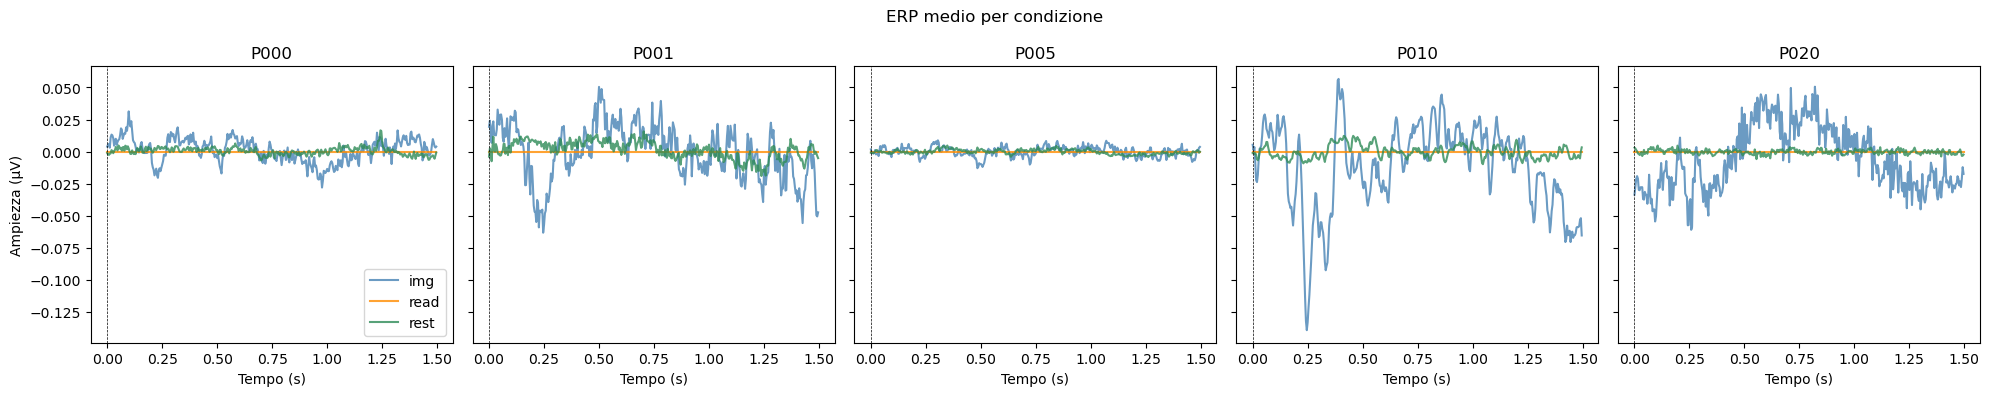

In [4]:
# ============================================================
# ERP MEDIO PER CONDIZIONE (media su trial e canali)
# ============================================================

fig, axes = plt.subplots(1, len(SUBJ_IDS), figsize=(4 * len(SUBJ_IDS), 4), sharey=True)

for ax, sid in zip(axes, SUBJ_IDS):
    for cond, color in [('img', 'steelblue'), ('read', 'darkorange'), ('rest', 'seagreen')]:
        ep = load_condition(sid, cond, DATA_ROOT)
        if len(ep) == 0:
            continue
        erp = ep.mean(axis=(0, 1))  # media su trial e canali → (384,)
        ax.plot(TIMES, erp, label=cond, color=color, alpha=0.8)
    ax.set_title(f'P{sid:03d}')
    ax.set_xlabel('Tempo (s)')
    ax.axvline(0, color='k', linestyle='--', linewidth=0.5)

axes[0].set_ylabel('Ampiezza (µV)')
axes[0].legend()
fig.suptitle('ERP medio per condizione')
plt.tight_layout()
plt.savefig(project_root / 'figures' / 'PB02_erp_comparison.png', dpi=150)
plt.show()

img:   0%|          | 0/5 [00:00<?, ?it/s]

read:   0%|          | 0/5 [00:00<?, ?it/s]

rest:   0%|          | 0/5 [00:00<?, ?it/s]

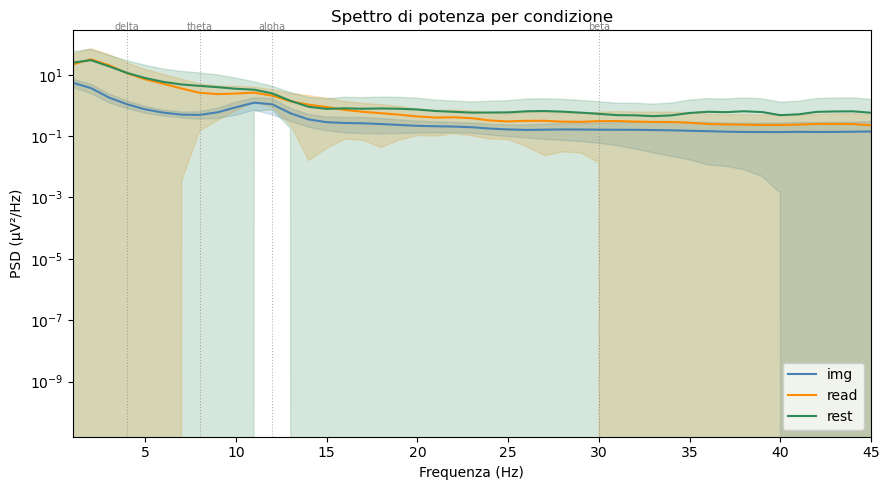

In [5]:
# ============================================================
# SPETTRO DI POTENZA PER CONDIZIONE (media su soggetti)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 5))

for cond, color in [('img', 'steelblue'), ('read', 'darkorange'), ('rest', 'seagreen')]:
    psds_all = []
    for sid in tqdm(SUBJ_IDS, desc=cond, leave=False):
        ep = load_condition(sid, cond, DATA_ROOT)
        if len(ep) == 0:
            continue
        freqs, psd = signal.welch(ep, fs=SFREQ, nperseg=SFREQ, axis=-1)  # (n, ch, f)
        psds_all.append(psd.mean(axis=(0, 1)))  # media su trial e canali → (f,)
    if psds_all:
        mean_psd = np.mean(psds_all, axis=0)
        std_psd  = np.std(psds_all, axis=0)
        ax.semilogy(freqs, mean_psd, label=cond, color=color)
        ax.fill_between(freqs, mean_psd - std_psd, mean_psd + std_psd, alpha=0.2, color=color)

for band, freq in [('delta', 4), ('theta', 8), ('alpha', 12), ('beta', 30)]:
    ax.axvline(freq, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax.text(freq, ax.get_ylim()[1], band, fontsize=7, color='gray', ha='center')

ax.set_xlim(1, 45)
ax.set_xlabel('Frequenza (Hz)')
ax.set_ylabel('PSD (µV²/Hz)')
ax.set_title('Spettro di potenza per condizione')
ax.legend()
plt.tight_layout()
plt.savefig(project_root / 'figures' / 'PB02_psd_comparison.png', dpi=150)
plt.show()

In [6]:
# ============================================================
# TEST STATISTICO: img vs read vs rest (Wilcoxon su varianza)
# Esteso a TUTTI i soggetti (i plot ERP/PSD sopra restano sui 5 esempi).
# NB: carica tutte le epoche di tutti i soggetti → qualche minuto.
# ============================================================
all_subj_v = sorted(set(int(d.name.split('_')[0][1:]) for d in DATA_ROOT.iterdir()
                        if d.is_dir() and d.name.startswith('P')))
print(f'Soggetti totali: {len(all_subj_v)}')

results = []
for sid in tqdm(all_subj_v, desc='Soggetti (varianza)'):
    row = {'subj': sid}
    for cond in ('img', 'read', 'rest'):
        try:
            ep = load_condition(sid, cond, DATA_ROOT)
        except Exception:
            ep = []
        if len(ep) > 0:
            row[f'var_{cond}'] = float(ep.var(axis=-1).mean())
            row[f'n_{cond}']   = len(ep)
    results.append(row)

df = pd.DataFrame(results)
df.to_csv(project_root / 'figures' / 'PB02_variance_per_subject.csv', index=False)

# Test appaiato: solo soggetti con TUTTE e tre le condizioni
df_full = df.dropna(subset=['var_img', 'var_read', 'var_rest'])
print(f'\nSoggetti con img+read+rest: {len(df_full)} / {len(df)}')
print('Mediana varianza:'
      f'  img={df_full.var_img.median():.1f}  read={df_full.var_read.median():.1f}  rest={df_full.var_rest.median():.1f}')
print(f'  img < read in {(df_full.var_img < df_full.var_read).mean()*100:.0f}% dei soggetti')
print(f'  img < rest in {(df_full.var_img < df_full.var_rest).mean()*100:.0f}% dei soggetti')

stat, pr = stats.wilcoxon(df_full['var_img'], df_full['var_read'])
print(f'\nWilcoxon img vs read (n={len(df_full)}): stat={stat:.1f}  p={pr:.2e}')
stat, ps = stats.wilcoxon(df_full['var_img'], df_full['var_rest'])
print(f'Wilcoxon img vs rest (n={len(df_full)}): stat={stat:.1f}  p={ps:.2e}')

print('\n5 var_img più basse:')
print(df_full.nsmallest(5, 'var_img')[['subj','var_img','var_read','var_rest']].to_string(index=False))
print('5 var_img più alte:')
print(df_full.nlargest(5, 'var_img')[['subj','var_img','var_read','var_rest']].to_string(index=False))


Soggetti totali: 91


Soggetti (varianza):   0%|          | 0/91 [00:00<?, ?it/s]


Soggetti con img+read+rest: 90 / 91
Mediana varianza:  img=31.0  read=100.9  rest=127.3
  img < read in 83% dei soggetti
  img < rest in 98% dei soggetti

Wilcoxon img vs read (n=90): stat=402.0  p=3.57e-11
Wilcoxon img vs rest (n=90): stat=56.0  p=1.12e-15

5 var_img più basse:
 subj   var_img   var_read    var_rest
   60 10.507626  49.018291   65.154373
    2 11.002608 584.109253  943.649536
   43 11.683860  29.949371  344.478668
   66 12.569875 810.681091 2162.276123
   56 14.102390 230.610870  267.646423
5 var_img più alte:
 subj     var_img    var_read    var_rest
   80 2761.490723 2469.359131 5424.829590
   85  635.235779  476.673248 1272.495483
   90  428.314941  380.041260  454.372314
   78  340.493042  322.242676  408.088440
   88  242.819138  217.278488  137.989655
